# Fire Detection — EfficientNetV2-S + TCN → Joint Fusion (20-Session Split)

## Architecture
- **Image Branch**: EfficientNetV2-S fine-tuned with progressive unfreezing + MixUp/CutMix augmentation
- **Sensor Branch**: TCN (dilations=[1,2,4,8], seq_len=30) with enriched interaction features
- **Fusion Strategy**: Learned meta-model (Logistic Regression on soft probabilities)
- **Fine-tuning rule**: Threshold tuning & meta-model trained **exclusively on validation data** (no test leakage)


## Split Strategy (No Data Leakage — 20 sessions)
| Split | Sessions | Purpose |
|---|---|---|
| Train | merged1–merged13 | Fit both individual models |
| Val   | merged14–merged16 | Threshold tuning + meta-model training |
| Test  | merged17–merged20 | Final evaluation ONLY — never touched during training |

## 0. Mount Drive & Setup

In [2]:
# Clone your GitHub repo
!git clone https://github.com/Neha-Reddy-16/FIRE-DETECTION-CAPSTONE.git

import os

# Path to the dataset
MERGED_DIR = "/content/FIRE-DETECTION-CAPSTONE/Merged"

assert os.path.exists(MERGED_DIR), f"Path not found: {MERGED_DIR}"

sessions = sorted(
    [d for d in os.listdir(MERGED_DIR) if os.path.isdir(os.path.join(MERGED_DIR, d))],
    key=lambda x: int(x.split('_')[0].replace('merged', ''))
)

print("Sessions:", sessions)

Cloning into 'FIRE-DETECTION-CAPSTONE'...
remote: Enumerating objects: 6820, done.
remote: Total 6820 (delta 0), reused 0 (delta 0), pack-reused 6820 (from 1)
Receiving objects: 100% (6820/6820), 557.90 MiB | 19.93 MiB/s, done.
Updating files: 100% (6777/6777), done.
Sessions: ['merged1_test', 'merged2_test', 'merged3_test', 'merged4_test', 'merged5_test', 'merged6_test', 'merged7_test', 'merged8_test', 'merged9_test', 'merged10_test', 'merged11_test', 'merged12_test', 'merged13_test', 'merged14_test', 'merged15_test', 'merged16_test', 'merged17_test', 'merged18_test', 'merged19_test', 'merged20_test']


## 1. Install & Import

In [3]:
!pip install -q tensorflow scikit-learn Pillow numpy pandas matplotlib seaborn keras-tcn

In [4]:
SEED = 42
import random, numpy as np, os, warnings
warnings.filterwarnings('ignore')

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, precision_score,
                              recall_score, accuracy_score, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression

print("Imports done")
print(f"TF version: {tf.__version__}")

Imports done
TF version: 2.19.0


## 2. Load Data & Session-Level Split (No Leakage)

**20 sessions → 13 train / 3 val / 4 test**  
Val is used for: threshold tuning + meta-model training. Test is final eval only.

In [5]:
# ── Load all sessions ────────────────────────────────────────────────────────
all_dfs = []
for s in sessions:
    csv_path = os.path.join(MERGED_DIR, s, 'data.csv')
    df = pd.read_csv(csv_path)
    df['session'] = s
    df['abs_image_path'] = df['image_path'].apply(
        lambda p: os.path.join(MERGED_DIR, s, p)
    )
    all_dfs.append(df)

data = pd.concat(all_dfs, ignore_index=True)
print(f"Total rows   : {len(data):,}")
print(f"Label distribution:\n{data['label'].value_counts()}")

Total rows   : 6,757
Label distribution:
label
safe    5615
fire    1142
Name: count, dtype: int64


In [6]:
# ── Session-level split (deterministic, no leakage) ─────────────────────────
sessions_sorted = sorted(
    data['session'].unique(),
    key=lambda x: int(x.split('_')[0].replace('merged', ''))
)
assert len(sessions_sorted) == 20, f"Expected 16 sessions, got {len(sessions_sorted)}"

TRAIN_SESSIONS = sessions_sorted[:13]   # merged1  – merged13
VAL_SESSIONS   = sessions_sorted[13:16] # merged14 – merged16
TEST_SESSIONS  = sessions_sorted[16:]   # merged17 – merged20

train_df = data[data['session'].isin(TRAIN_SESSIONS)].copy().reset_index(drop=True)
val_df   = data[data['session'].isin(VAL_SESSIONS)].copy().reset_index(drop=True)
test_df  = data[data['session'].isin(TEST_SESSIONS)].copy().reset_index(drop=True)

# Verify no leakage
assert not set(TRAIN_SESSIONS) & set(VAL_SESSIONS)
assert not set(TRAIN_SESSIONS) & set(TEST_SESSIONS)
assert not set(VAL_SESSIONS)   & set(TEST_SESSIONS)

def print_split_stats(name, df):
    total = len(df)
    fire  = (df['label'] == 'fire').sum()
    safe  = (df['label'] == 'safe').sum()
    print(f"{name}: {total:,} rows | fire={fire:,} ({fire/total:.1%}) | safe={safe:,} ({safe/total:.1%})")

print_split_stats("TRAIN", train_df)
print_split_stats("VAL  ", val_df)
print_split_stats("TEST ", test_df)
print("\nNo data leakage detected")

TRAIN: 3,972 rows | fire=716 (18.0%) | safe=3,256 (82.0%)
VAL  : 703 rows | fire=117 (16.6%) | safe=586 (83.4%)
TEST : 2,082 rows | fire=309 (14.8%) | safe=1,773 (85.2%)

No data leakage detected


In [7]:
# ── Print sessions in each split ────────────────────────────────────────────

print("TRAIN SESSIONS:")
for s in TRAIN_SESSIONS:
    print("  ", s)

print("\nVAL SESSIONS:")
for s in VAL_SESSIONS:
    print("  ", s)

print("\nTEST SESSIONS:")
for s in TEST_SESSIONS:
    print("  ", s)

TRAIN SESSIONS:
   merged1_test
   merged2_test
   merged3_test
   merged4_test
   merged5_test
   merged6_test
   merged7_test
   merged8_test
   merged9_test
   merged10_test
   merged11_test
   merged12_test
   merged13_test

VAL SESSIONS:
   merged14_test
   merged15_test
   merged16_test

TEST SESSIONS:
   merged17_test
   merged18_test
   merged19_test
   merged20_test


## 3. Feature Engineering — Sensor Features (No Leakage)

All rolling/slope features computed **within each session independently**.  
**New in v2**: ratio features (`mq2/mq135`, `temp×mq2`) capture fire chemistry interactions.

In [8]:
SHORT_WIN = 5
LONG_WIN  = 30

def add_features(df):
    """Compute temporal + ratio features per session (no cross-session leakage)."""
    parts = []
    for session, grp in df.groupby('session', sort=False):
        grp = grp.copy().sort_values('timestamp')

        # ── Per-sensor temporal features ──────────────────────────────────────
        for col in ['temperature', 'mq135', 'mq2']:
            grp[f'{col}_delta']         = grp[col].diff().fillna(0)
            grp[f'{col}_accel']         = grp[f'{col}_delta'].diff().fillna(0)
            grp[f'{col}_roll_mean_s']   = grp[col].rolling(SHORT_WIN, min_periods=1).mean()
            grp[f'{col}_roll_std_s']    = grp[col].rolling(SHORT_WIN, min_periods=1).std().fillna(0)
            grp[f'{col}_baseline']      = grp[col].rolling(LONG_WIN,  min_periods=1).mean()
            grp[f'{col}_dev_from_base'] = grp[col] - grp[f'{col}_baseline']
            grp[f'{col}_slope']         = grp[col].rolling(SHORT_WIN, min_periods=2).apply(
                lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) > 1 else 0,
                raw=True
            ).fillna(0)
            grp[f'{col}_cumsum_delta']  = grp[f'{col}_delta'].cumsum()

        # ── Cross-sensor interaction features─────────────────────
        eps = 1e-6
        grp['mq2_mq135_ratio']   = grp['mq2']         / (grp['mq135'] + eps)
        grp['temp_x_mq2']        = grp['temperature']  * grp['mq2']
        grp['temp_x_mq135']      = grp['temperature']  * grp['mq135']

        parts.append(grp)
    return pd.concat(parts).reset_index(drop=True)

print('🔧 Computing features...')
train_df = add_features(train_df)
val_df   = add_features(val_df)
test_df  = add_features(test_df)

label_map = {'fire': 1, 'safe': 0}
train_df['label_enc'] = train_df['label'].map(label_map)
val_df['label_enc']   = val_df['label'].map(label_map)
test_df['label_enc']  = test_df['label'].map(label_map)

print('Features added')
print(f'Train shape: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}')

🔧 Computing features...
Features added
Train shape: (3972, 39) | Val: (703, 39) | Test: (2082, 39)


## 4. EfficientNetV2-S — Image Model

**Upgrades over v1:**
- Backbone: `EfficientNetV2-S` (faster training, better accuracy than B1)
- Input size: 384×384 (recommended for V2-S)
- Progressive unfreezing: Stage 1 = top layers only → Stage 2 = fine-tune last 3 blocks
- Augmentation: MixUp + CutMix added on top of standard augmentation

In [9]:
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effnetv2_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

EFFNET_SIZE = (384, 384)
BATCH_SIZE  = 16

# ── Focal Loss ────────────────────────────────────────────────────────────────
def focal_loss(alpha=0.4, gamma=2.0):
    def loss(y_true, y_pred):
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow((1 - p_t), gamma) * bce
    return loss

# ── MixUp augmentation ────────────────────────────────────────────────────────
def mixup_batch(X, y, alpha=0.2):
    """Apply MixUp to a batch of images and labels."""
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(len(X))
    X_mix = lam * X + (1 - lam) * X[idx]
    y_mix = lam * y + (1 - lam) * y[idx]
    return X_mix.astype(np.float32), y_mix.astype(np.float32)

# ── CutMix augmentation ───────────────────────────────────────────────────────
def cutmix_batch(X, y, alpha=1.0):
    """Apply CutMix to a batch of images and labels."""
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(len(X))
    H, W = X.shape[1], X.shape[2]

    cut_ratio = np.sqrt(1 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    X_mix = X.copy()
    X_mix[:, y1:y2, x1:x2, :] = X[idx, y1:y2, x1:x2, :]
    lam_real = 1 - (x2 - x1) * (y2 - y1) / (H * W)
    y_mix = lam_real * y + (1 - lam_real) * y[idx]
    return X_mix.astype(np.float32), y_mix.astype(np.float32)

# ── Custom generator with MixUp / CutMix ─────────────────────────────────────
def make_augmented_generator(df, batch_size, shuffle=True, use_mixup=True, use_cutmix=True):
    """Wrap a Keras flow_from_dataframe with optional MixUp/CutMix."""
    datagen = ImageDataGenerator(
        preprocessing_function=effnetv2_preprocess,
        horizontal_flip=True,
        vertical_flip=False,
        brightness_range=[0.75, 1.25],
        rotation_range=15,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        fill_mode='nearest'
    )
    gen = datagen.flow_from_dataframe(
        df[['abs_image_path', 'label']],
        x_col='abs_image_path', y_col='label',
        target_size=EFFNET_SIZE, batch_size=batch_size,
        class_mode='binary', shuffle=shuffle, seed=SEED
    )
    if not (use_mixup or use_cutmix):
        return gen

    def augmented_gen():
        for X_batch, y_batch in gen:
            choice = np.random.rand()
            if use_mixup and choice < 0.33:
                X_batch, y_batch = mixup_batch(X_batch, y_batch)
            elif use_cutmix and choice < 0.66:
                X_batch, y_batch = cutmix_batch(X_batch, y_batch)
            yield X_batch, y_batch

    return augmented_gen()

eval_datagen = ImageDataGenerator(preprocessing_function=effnetv2_preprocess)

val_gen = eval_datagen.flow_from_dataframe(
    val_df[['abs_image_path', 'label']],
    x_col='abs_image_path', y_col='label',
    target_size=EFFNET_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)
test_gen = eval_datagen.flow_from_dataframe(
    test_df[['abs_image_path', 'label']],
    x_col='abs_image_path', y_col='label',
    target_size=EFFNET_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)
train_gen_base = eval_datagen.flow_from_dataframe(
    train_df[['abs_image_path', 'label']],
    x_col='abs_image_path', y_col='label',
    target_size=EFFNET_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Class indices:', val_gen.class_indices)

cw_arr = compute_class_weight('balanced',
                               classes=np.unique(train_df['label_enc']),
                               y=train_df['label_enc'])
class_weight_effnet = dict(enumerate(cw_arr))
print('Class weights:', class_weight_effnet)

Found 703 validated image filenames belonging to 2 classes.
Found 2082 validated image filenames belonging to 2 classes.
Found 3963 validated image filenames belonging to 2 classes.
Train: 3972 | Val: 703 | Test: 2082
Class indices: {'fire': 0, 'safe': 1}
Class weights: {0: np.float64(0.60995085995086), 1: np.float64(2.7737430167597767)}


In [10]:
# ── Build EfficientNetV2-S — Stage 1: frozen backbone ────────────────────────
tf.random.set_seed(SEED)

base_model = EfficientNetV2S(weights='imagenet', include_top=False,
                              input_shape=(*EFFNET_SIZE, 3))
base_model.trainable = False   # Stage 1: freeze all

inp   = Input(shape=(*EFFNET_SIZE, 3)) #3 channels for R G B
x     = base_model(inp, training=False) # to use pretrained model
x     = GlobalAveragePooling2D()(x)
x     = BatchNormalization()(x)
x     = Dropout(0.4)(x)
x     = Dense(256, activation='relu')(x)
x     = Dropout(0.3)(x)
out   = Dense(1, activation='sigmoid')(x)

effnet_model = Model(inp, out)
effnet_model.compile(
    optimizer=Adam(1e-3),     # higher LR while backbone frozen
    loss=focal_loss(alpha=0.4, gamma=2.0),
    metrics=['accuracy']
)

total     = effnet_model.count_params()
trainable = sum(np.prod(w.shape) for w in effnet_model.trainable_weights)
print(f'Stage 1 — Total params: {total:,} | Trainable: {trainable:,}')



82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Stage 1 — Total params: 20,664,673 | Trainable: 330,753


In [11]:
# ── Stage 1: Train classification head (frozen backbone) ─────────────────────
STEPS_PER_EPOCH  = int(np.ceil(len(train_df) / BATCH_SIZE))
VALIDATION_STEPS = int(np.ceil(len(val_df)   / BATCH_SIZE))

train_aug_gen = make_augmented_generator(train_df, BATCH_SIZE,
                                          use_mixup=True, use_cutmix=True)

stage1_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1),
]

print("Stage 1: Training classification head (backbone frozen)...")
history_s1 = effnet_model.fit(
    train_aug_gen,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=8,
    validation_data=val_gen,
    validation_steps=VALIDATION_STEPS,
    callbacks=stage1_callbacks,
    verbose=1
)
print('Stage 1 complete')

Found 3963 validated image filenames belonging to 2 classes.
Stage 1: Training classification head (backbone frozen)...
Epoch 1/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 323s 997ms/step - accuracy: 0.7540 - loss: 0.0643 - val_accuracy: 0.8890 - val_loss: 0.0388 - learning_rate: 0.0010
Epoch 2/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 170s 686ms/step - accuracy: 0.7942 - loss: 0.0389 - val_accuracy: 0.8734 - val_loss: 0.0467 - learning_rate: 0.0010
Epoch 3/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 169s 683ms/step - accuracy: 0.7984 - loss: 0.0257 - val_accuracy: 0.9246 - val_loss: 0.0279 - learning_rate: 0.0010
Epoch 4/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 185s 744ms/step - accuracy: 0.7733 - loss: 0.0215 - val_accuracy: 0.8193 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 5/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 175s 704ms/step - accuracy: 0.7819 - loss: 0.0182 - val_accuracy: 0.9502 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 6/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 175s 703ms/step - accuracy: 0.7997 - loss: 0.0173 - val_accuracy: 

In [12]:
# ── Stage 2: Progressive unfreezing — unfreeze last 3 blocks ─────────────────
# Unfreeze from block5 onwards (V2-S has blocks 0-6)
UNFREEZE_FROM = 'block5a_expand_conv'

found = False
for layer in base_model.layers:
    if layer.name == UNFREEZE_FROM:
        found = True
    layer.trainable = found

trainable2 = sum(np.prod(w.shape) for w in effnet_model.trainable_weights)
print(f'Stage 2 — Trainable params: {trainable2:,} (unfrozen from {UNFREEZE_FROM})')

# Lower LR for fine-tuning
effnet_model.compile(
    optimizer=Adam(1e-5),   # 10× lower LR for fine-tuning
    loss=focal_loss(alpha=0.4, gamma=2.0),
    metrics=['accuracy']
)

CHECKPOINT_PATH = '/content/best_effnetv2_val.keras'
stage2_callbacks = [
    EarlyStopping(monitor='val_loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-8, verbose=1),
    ModelCheckpoint(CHECKPOINT_PATH, monitor='val_loss',
                    save_best_only=True, verbose=1)
]

# Fresh augmented generator
train_aug_gen2 = make_augmented_generator(train_df, BATCH_SIZE,
                                           use_mixup=True, use_cutmix=True)

print("\nStage 2: Fine-tuning last 3 blocks...")

history_s2 = effnet_model.fit(
    train_aug_gen2,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=10,
    validation_data=val_gen,
    validation_steps=VALIDATION_STEPS,
    callbacks=stage2_callbacks,
    verbose=1
)

print('Stage 2 (fine-tuning) complete')

Stage 2 — Trainable params: 18,686,665 (unfrozen from block5a_expand_conv)
Found 3963 validated image filenames belonging to 2 classes.

Stage 2: Fine-tuning last 3 blocks...
Epoch 1/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7398 - loss: 0.0292
Epoch 1: val_loss improved from None to 0.01451, saving model to /content/best_effnetv2_val.keras

Epoch 1: finished saving model to /content/best_effnetv2_val.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.7602 - loss: 0.0246 - val_accuracy: 0.9772 - val_loss: 0.0145 - learning_rate: 1.0000e-05
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.8038 - loss: 0.0156
Epoch 2: val_loss improved from 0.01451 to 0.01006, saving model to /content/best_effnetv2_val.keras

Epoch 2: finished saving model to /content/best_effnetv2_val.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 200s 804ms/step - accuracy: 0.8130 - loss: 0.0155 - val_accuracy: 0.9900 - val_loss: 0.0101 - learning_rate: 1.0000e-05
Epoch 3/10
249/249 ━━━

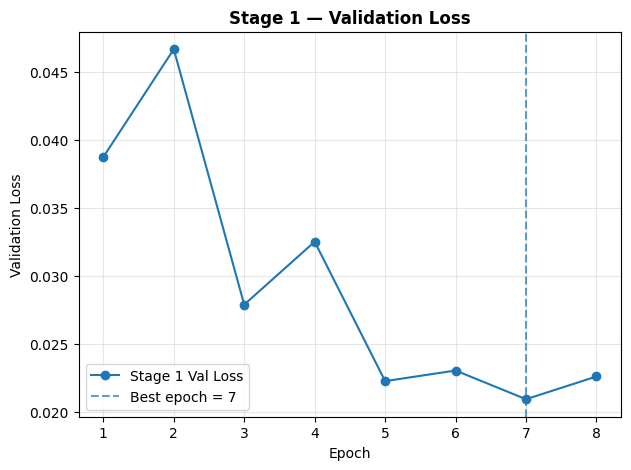

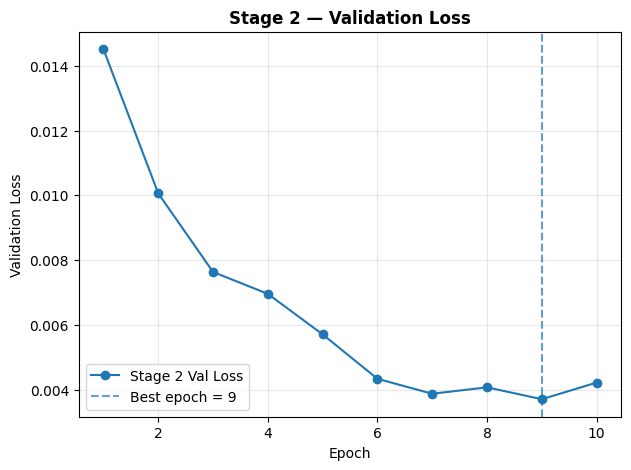

In [13]:
# ── Separate Val Loss Graphs ────────────────────────────────────────────────

s1_loss = history_s1.history['val_loss']
s2_loss = history_s2.history['val_loss']

# -------- Stage 1 --------
plt.figure(figsize=(7, 5))
epochs_s1 = range(1, len(s1_loss) + 1)

plt.plot(epochs_s1, s1_loss, marker='o', label='Stage 1 Val Loss')

best_s1 = np.argmin(s1_loss) + 1
plt.axvline(best_s1, linestyle='--', alpha=0.7,
            label=f'Best epoch = {best_s1}')

plt.title('Stage 1 — Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# -------- Stage 2 --------
plt.figure(figsize=(7, 5))
epochs_s2 = range(1, len(s2_loss) + 1)

plt.plot(epochs_s2, s2_loss, marker='o', label='Stage 2 Val Loss')

best_s2 = np.argmin(s2_loss) + 1
plt.axvline(best_s2, linestyle='--', alpha=0.7,
            label=f'Best epoch = {best_s2}')

plt.title('Stage 2 — Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
# ── EfficientNetV2-S: threshold tuning on VALIDATION set ─────────────────────
# RULE: threshold is tuned on val only
val_gen.reset()
val_probs_eff = effnet_model.predict(val_gen, verbose=1).flatten()

fire_idx_effnet = val_gen.class_indices.get('fire', 1)
if fire_idx_effnet == 0:
    val_probs_eff = 1 - val_probs_eff

y_val_eff = np.array(val_gen.classes)
if fire_idx_effnet == 0:
    y_val_eff = 1 - y_val_eff

# Sweep thresholds on val
best_thr_eff, best_f1_eff = 0.5, 0.0
print(f"{'Threshold':>10} | {'F1':>8} | {'Recall':>8} | {'Precision':>10}")
print('-' * 50)
for t in np.arange(0.10, 0.90, 0.01):
    preds = (val_probs_eff >= t).astype(int)
    f1    = f1_score(y_val_eff, preds, zero_division=0)
    if f1 > best_f1_eff:
        best_f1_eff, best_thr_eff = f1, t
    if round(t, 2) % 0.05 < 0.011:
        rec  = recall_score(y_val_eff, preds, zero_division=0)
        prec = precision_score(y_val_eff, preds, zero_division=0)
        print(f"{t:>10.2f} | {f1:>8.4f} | {rec:>8.4f} | {prec:>10.4f}")

EFFNET_THRESHOLD = best_thr_eff
print(f"\nBest EfficientNetV2-S threshold (val): {EFFNET_THRESHOLD:.3f}  F1={best_f1_eff:.4f}")

val_preds_eff = (val_probs_eff >= EFFNET_THRESHOLD).astype(int)
print("\nValidation Report @ Best Threshold:")
print(classification_report(y_val_eff, val_preds_eff, target_names=['safe','fire']))

44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 511ms/step
 Threshold |       F1 |   Recall |  Precision
--------------------------------------------------
      0.10 |   0.3811 |   1.0000 |     0.2354
      0.11 |   0.3874 |   1.0000 |     0.2402
      0.16 |   0.4597 |   1.0000 |     0.2985
      0.20 |   0.5585 |   1.0000 |     0.3874
      0.21 |   0.5985 |   1.0000 |     0.4270
      0.26 |   0.8731 |   1.0000 |     0.7748
      0.31 |   0.9915 |   1.0000 |     0.9832
      0.36 |   1.0000 |   1.0000 |     1.0000
      0.40 |   1.0000 |   1.0000 |     1.0000
      0.41 |   1.0000 |   1.0000 |     1.0000
      0.46 |   0.9957 |   0.9915 |     1.0000
      0.51 |   0.9870 |   0.9744 |     1.0000
      0.55 |   0.9692 |   0.9402 |     1.0000
      0.56 |   0.9692 |   0.9402 |     1.0000
      0.61 |   0.9646 |   0.9316 |     1.0000
      0.66 |   0.9217 |   0.8547 |     1.0000
      0.71 |   0.8857 |   0.7949 |     1.0000
      0.76 |   0.8182 |   0.6923 |     1.0000
      0.80 |   0.7143 |   0.5556 

## 5. TCN — Time-Series Sensor Model

- `seq_len=30` — captures slower fire onset patterns
- `dilations=[1,2,4,8]` — wider receptive field (~240 timesteps)
- 11 features including ratio/interaction features

In [44]:
# ── TCN Feature Set (11 features) ────────────────────────────────────────────
TCN_FEATURES = [
    # Deviation from rolling baseline
    'temperature_dev_from_base',
    'mq2_dev_from_base',
    'mq135_dev_from_base',
    # Rate of change
    'temperature_delta',
    'mq2_delta',
    'mq135_delta',
    # Trend
    'temperature_slope',
    # Binary sensor
    'flame',
    # Cross-sensor interaction features (NEW)
    'mq2_mq135_ratio',
    'temp_x_mq2',
    'temp_x_mq135',
]

missing = [f for f in TCN_FEATURES if f not in train_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")
print(f"TCN features ({len(TCN_FEATURES)}): {TCN_FEATURES}")

TCN features (11): ['temperature_dev_from_base', 'mq2_dev_from_base', 'mq135_dev_from_base', 'temperature_delta', 'mq2_delta', 'mq135_delta', 'temperature_slope', 'flame', 'mq2_mq135_ratio', 'temp_x_mq2', 'temp_x_mq135']


In [45]:
# ── Build TCN sequences within sessions (no cross-session leakage) ───────────
SEQ_LEN = 30

def create_sequences(df, feature_cols, seq_len):
    """Sliding-window sequences within each session independently."""
    X, y = [], []
    for session, grp in df.groupby('session', sort=False):
        grp  = grp.sort_values('timestamp').reset_index(drop=True)
        vals = grp[feature_cols].values
        lbls = grp['label_enc'].values
        for i in range(seq_len, len(vals)):
            X.append(vals[i - seq_len:i])
            y.append(lbls[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

X_train_tcn, y_train_tcn = create_sequences(train_df, TCN_FEATURES, SEQ_LEN)
X_val_tcn,   y_val_tcn   = create_sequences(val_df,   TCN_FEATURES, SEQ_LEN)
X_test_tcn,  y_test_tcn  = create_sequences(test_df,  TCN_FEATURES, SEQ_LEN)

print(f"X_train: {X_train_tcn.shape}  y_train: {y_train_tcn.shape}")
print(f"X_val  : {X_val_tcn.shape}    y_val  : {y_val_tcn.shape}")
print(f"X_test : {X_test_tcn.shape}   y_test : {y_test_tcn.shape}")

X_train: (3582, 30, 11)  y_train: (3582,)
X_val  : (613, 30, 11)    y_val  : (613,)
X_test : (1962, 30, 11)   y_test : (1962,)


In [46]:
# ── Scale — fit ONLY on train ─────────────────────────────────────────────────
scaler_tcn = StandardScaler()
n_feat = len(TCN_FEATURES)

X_train_tcn_scaled = scaler_tcn.fit_transform(
    X_train_tcn.reshape(-1, n_feat)).reshape(X_train_tcn.shape)
X_val_tcn_scaled   = scaler_tcn.transform(
    X_val_tcn.reshape(-1, n_feat)).reshape(X_val_tcn.shape)
X_test_tcn_scaled  = scaler_tcn.transform(
    X_test_tcn.reshape(-1, n_feat)).reshape(X_test_tcn.shape)

print("Scaled (fit on train only)")

Scaled (fit on train only)


In [47]:
# ── Build TCN model───────────────────────────────────
from tcn import TCN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def focal_loss_tcn(alpha=0.6, gamma=2.0):
    def loss(y_true, y_pred):
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow((1 - p_t), gamma) * bce
    return loss

tf.random.set_seed(SEED)

model_tcn = Sequential([
    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8],
        dropout_rate=0.2,
        return_sequences=False,
        input_shape=(SEQ_LEN, n_feat)
    ),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_tcn.compile(
    optimizer='adam',
    loss=focal_loss_tcn(alpha=0.6, gamma=2.0),
    metrics=['accuracy']
)
model_tcn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_1 (TCN)                     │ (None, 64)             │        89,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,633 (365.75 KB)

 Trainable params: 93,633 (365.75 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# ── Train TCN ─────────────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

class_weight_tcn = {0: 1, 1: 2}

tcn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

tcn_history = model_tcn.fit(
    X_train_tcn_scaled, y_train_tcn,
    validation_data=(X_val_tcn_scaled, y_val_tcn),
    epochs=40,
    batch_size=64,
    class_weight=class_weight_tcn,
    callbacks=tcn_callbacks,
    verbose=1
)
print('TCN training complete')

Epoch 1/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 173ms/step - accuracy: 0.7454 - loss: 0.4710 - val_accuracy: 0.9070 - val_loss: 0.0682 - learning_rate: 0.0010
Epoch 2/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8428 - loss: 0.1045 - val_accuracy: 0.9396 - val_loss: 0.0571 - learning_rate: 0.0010
Epoch 3/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8908 - loss: 0.0731 - val_accuracy: 0.9429 - val_loss: 0.0549 - learning_rate: 0.0010
Epoch 4/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9238 - loss: 0.0533 - val_accuracy: 0.9233 - val_loss: 0.0644 - learning_rate: 0.0010
Epoch 5/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9363 - loss: 0.0459 - val_accuracy: 0.9511 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 6/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9397 - loss: 0.0432 - val_accuracy: 0.9462 - val_loss: 0.0578 - learning_rate: 0.0010
Epoch 7/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9481 - loss: 0.0378 - val_accurac

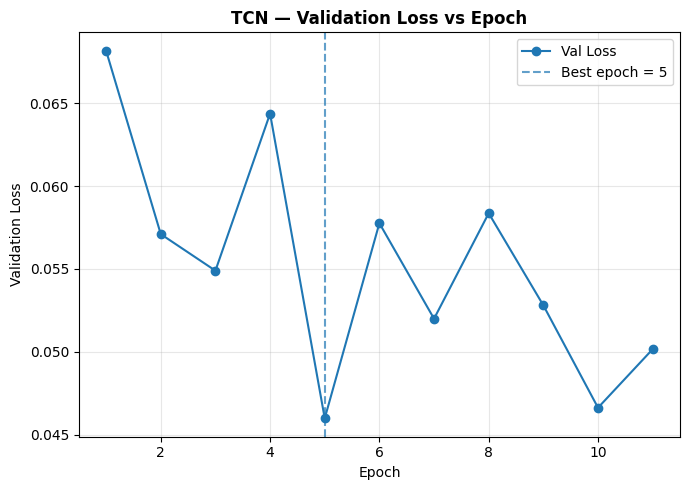

In [49]:
# ── TCN: Validation Loss vs Epoch ───────────────────────────────────────────

val_loss = tcn_history.history['val_loss']
epochs = range(1, len(val_loss) + 1)

plt.figure(figsize=(7, 5))

plt.plot(epochs, val_loss, marker='o', label='Val Loss')

# Mark best epoch
best_epoch = np.argmin(val_loss) + 1
plt.axvline(best_epoch, linestyle='--', alpha=0.7,
            label=f'Best epoch = {best_epoch}')

plt.title('TCN — Validation Loss vs Epoch', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# ── TCN: threshold tuning on VALIDATION set ──────────────────────────────────
#  RULE: only val set used for threshold selection
val_probs_tcn = model_tcn.predict(X_val_tcn_scaled, verbose=0).flatten()

best_thresh_tcn, best_f1_tcn = 0.45, 0.0
print(f"{'Threshold':>10} | {'F1':>8} | {'Recall':>8} | {'Precision':>10}")
print('-' * 50)
for t in np.arange(0.20, 0.80, 0.01):
    preds = (val_probs_tcn >= t).astype(int)
    f1    = f1_score(y_val_tcn, preds, zero_division=0)
    if f1 > best_f1_tcn:
        best_f1_tcn, best_thresh_tcn = f1, t
    if round(t, 2) % 0.05 < 0.011:
        rec  = recall_score(y_val_tcn, preds, zero_division=0)
        prec = precision_score(y_val_tcn, preds, zero_division=0)
        print(f"{t:>10.2f} | {f1:>8.4f} | {rec:>8.4f} | {prec:>10.4f}")

TCN_THRESHOLD = best_thresh_tcn
print(f"\nBest TCN threshold (val): {TCN_THRESHOLD:.3f}  F1={best_f1_tcn:.4f}")

val_preds_tcn = (val_probs_tcn >= TCN_THRESHOLD).astype(int)
print("\nValidation Report @ Best TCN Threshold:")
print(classification_report(y_val_tcn, val_preds_tcn, target_names=['safe','fire']))

 Threshold |       F1 |   Recall |  Precision
--------------------------------------------------
      0.20 |   0.1115 |   0.8649 |     0.0596
      0.21 |   0.1139 |   0.8649 |     0.0610
      0.26 |   0.1379 |   0.8649 |     0.0749
      0.31 |   0.1783 |   0.8649 |     0.0994
      0.36 |   0.2540 |   0.8649 |     0.1488
      0.40 |   0.3750 |   0.8108 |     0.2439
      0.41 |   0.4110 |   0.8108 |     0.2752
      0.46 |   0.5833 |   0.7568 |     0.4746
      0.51 |   0.6582 |   0.7027 |     0.6190
      0.55 |   0.6400 |   0.6486 |     0.6316
      0.56 |   0.6389 |   0.6216 |     0.6571
      0.61 |   0.6769 |   0.5946 |     0.7857
      0.66 |   0.7000 |   0.5676 |     0.9130
      0.71 |   0.6552 |   0.5135 |     0.9048
      0.76 |   0.6429 |   0.4865 |     0.9474
      0.80 |   0.4490 |   0.2973 |     0.9167

Best TCN threshold (val): 0.630  F1=0.7097

Validation Report @ Best TCN Threshold:
              precision    recall  f1-score   support

        safe       0.97    

## 6. TCN Feature Importance (Circular-Shift Permutation)

Circular shift preserves within-window dynamics but breaks feature-label temporal alignment — gives reliable importance estimates.

Base F1 (TCN, validation): 0.7097


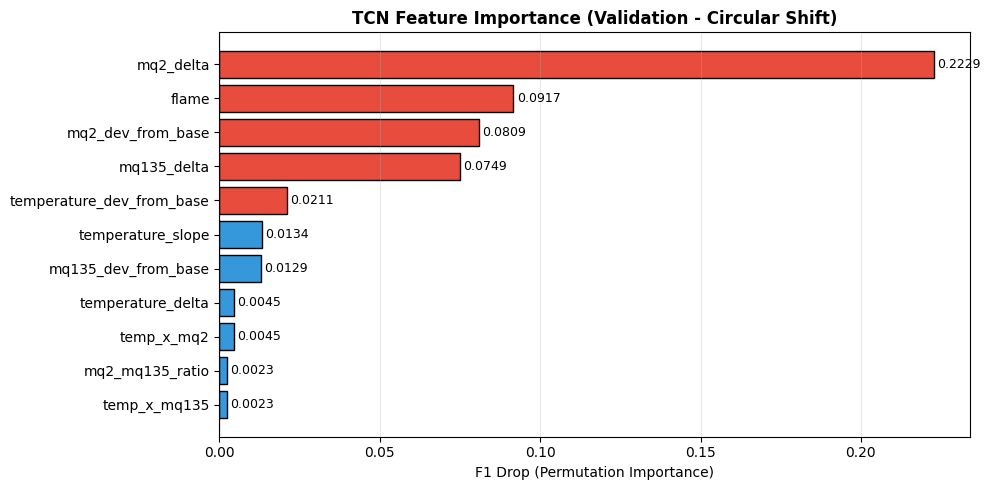


Feature Importance Ranking (Validation):
  1. mq2_delta                           0.22290
  2. flame                               0.09166
  3. mq2_dev_from_base                   0.08092
  4. mq135_delta                         0.07486
  5. temperature_dev_from_base           0.02111
  6. temperature_slope                   0.01338
  7. mq135_dev_from_base                 0.01290
  8. temperature_delta                   0.00451
  9. temp_x_mq2                          0.00451
  10. mq2_mq135_ratio                     0.00225
  11. temp_x_mq135                        0.00225


In [51]:
# ── Circular-shift permutation importance (VALIDATION) ──────────────────────

base_preds = (model_tcn.predict(X_val_tcn_scaled, verbose=0).flatten()
              >= TCN_THRESHOLD).astype(int)

base_f1 = f1_score(y_val_tcn, base_preds)
print(f'Base F1 (TCN, validation): {base_f1:.4f}')

importance_scores = {}
N_REPEATS = 5

for fi, feat_name in enumerate(TCN_FEATURES):
    drop_scores = []

    for _ in range(N_REPEATS):
        X_perm = X_val_tcn_scaled.copy()

        # random circular shifts
        shifts = np.random.randint(1, X_perm.shape[1], size=X_perm.shape[0])

        for si, shift in enumerate(shifts):
            X_perm[si, :, fi] = np.roll(X_perm[si, :, fi], shift)

        preds_p = (model_tcn.predict(X_perm, verbose=0).flatten()
                   >= TCN_THRESHOLD).astype(int)

        drop_scores.append(
            max(0.0, base_f1 - f1_score(y_val_tcn, preds_p, zero_division=0))
        )

    importance_scores[feat_name] = float(np.mean(drop_scores))

# Sort importance
feat_imp = pd.Series(importance_scores).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if v > 0.02 else '#3498db' for v in feat_imp.values]

bars = plt.barh(feat_imp.index[::-1], feat_imp.values[::-1],
                color=colors[::-1], edgecolor='black')

plt.xlabel('F1 Drop (Permutation Importance)')
plt.title('TCN Feature Importance (Validation - Circular Shift)', fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, feat_imp.values[::-1]):
    plt.text(val + 0.001,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}',
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/tcn_feature_importance_val.png', dpi=120, bbox_inches='tight')
plt.show()

# Ranking print
print("\nFeature Importance Ranking (Validation):")
for rank, (feat, score) in enumerate(feat_imp.items(), 1):
    print(f"  {rank}. {feat:<35} {score:.5f}")

## 7. Soft Probability Fusion — Learned Meta-Model

**Strategy:**
1. Align EfficientNetV2-S and TCN predictions to the same rows (TCN-compatible subset)
2. On **validation set**: train a `LogisticRegression` meta-model on `[effnet_prob, tcn_prob]`
3. On **test set**: evaluate individual models + meta-model fusion

This replaces the hard OR logic with a learned combination — probabilities carry confidence information the OR logic discards.

In [52]:
# ── Step 1: Collect aligned predictions on VALIDATION set ────────────────────
# Val rows that have TCN sequences (skip first SEQ_LEN per session)
val_df_reset = val_df.reset_index(drop=True)

val_gen.reset()
effnet_probs_val_all = effnet_model.predict(val_gen, verbose=0).flatten()
if fire_idx_effnet == 0:
    effnet_probs_val_all = 1 - effnet_probs_val_all
effnet_probs_val_all = effnet_probs_val_all[:len(val_df_reset)]

y_val_aligned, eff_probs_val_aligned, tcn_probs_val_aligned = [], [], []
cur = 0
for session, grp in val_df_reset.groupby('session', sort=False):
    grp = grp.reset_index(drop=True)
    for i in range(SEQ_LEN, len(grp)):
        y_val_aligned.append(grp.loc[i, 'label_enc'])
        eff_probs_val_aligned.append(effnet_probs_val_all[cur + i])
    cur += len(grp)

# TCN val probs already aligned
tcn_probs_val_aligned = val_probs_tcn   # from threshold tuning cell

y_val_aligned        = np.array(y_val_aligned)
eff_probs_val_aligned = np.array(eff_probs_val_aligned)
tcn_probs_val_aligned = np.array(tcn_probs_val_aligned)

assert len(y_val_aligned) == len(tcn_probs_val_aligned) == len(eff_probs_val_aligned), \
    f"Length mismatch: y={len(y_val_aligned)}, eff={len(eff_probs_val_aligned)}, tcn={len(tcn_probs_val_aligned)}"

print(f"Val aligned rows: {len(y_val_aligned):,}")

Val aligned rows: 613


In [53]:
# ── Step 2: Train meta-model on VALIDATION set ───────────────────────────────
# RULE: meta-model is trained on val — this IS the fine-tuning on val
# It learns the optimal combination of both probability streams

X_meta_val = np.stack([eff_probs_val_aligned, tcn_probs_val_aligned], axis=1)
y_meta_val = y_val_aligned

meta_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)
meta_model.fit(X_meta_val, y_meta_val)

meta_val_preds = meta_model.predict(X_meta_val)
meta_val_probs = meta_model.predict_proba(X_meta_val)[:, 1]

print("Meta-model weights (learned on val):")
print(f"  EfficientNetV2-S coeff : {meta_model.coef_[0][0]:.4f}")
print(f"  TCN coeff              : {meta_model.coef_[0][1]:.4f}")
print(f"  Intercept              : {meta_model.intercept_[0]:.4f}")

print("\n=== Meta-Model — Validation Set ===")
print(classification_report(y_meta_val, meta_val_preds, target_names=['safe','fire']))

Meta-model weights (learned on val):
  EfficientNetV2-S coeff : 8.7926
  TCN coeff              : 2.1876
  Intercept              : -4.8558

=== Meta-Model — Validation Set ===
              precision    recall  f1-score   support

        safe       1.00      1.00      1.00       576
        fire       1.00      1.00      1.00        37

    accuracy                           1.00       613
   macro avg       1.00      1.00      1.00       613
weighted avg       1.00      1.00      1.00       613



In [54]:
# ── TCN: Generate TEST probabilities ────────────────────────────────────────
print("Generating TCN test predictions...")

test_probs_tcn = model_tcn.predict(X_test_tcn_scaled, verbose=0).flatten()

print("Done!")
print("Shape:", test_probs_tcn.shape)

Generating TCN test predictions...
Done!
Shape: (1962,)


In [55]:
# ── Step 3: Collect aligned predictions on TEST set ──────────────────────────
test_df_reset = test_df.reset_index(drop=True)

test_gen.reset()
effnet_probs_test_all = effnet_model.predict(test_gen, verbose=0).flatten()
if fire_idx_effnet == 0:
    effnet_probs_test_all = 1 - effnet_probs_test_all
effnet_probs_test_all = effnet_probs_test_all[:len(test_df_reset)]

y_test_aligned, eff_probs_test_aligned = [], []
cur = 0
for session, grp in test_df_reset.groupby('session', sort=False):
    grp = grp.reset_index(drop=True)
    for i in range(SEQ_LEN, len(grp)):
        y_test_aligned.append(grp.loc[i, 'label_enc'])
        eff_probs_test_aligned.append(effnet_probs_test_all[cur + i])
    cur += len(grp)

y_test_aligned        = np.array(y_test_aligned)
eff_probs_test_aligned = np.array(eff_probs_test_aligned)
tcn_probs_test_aligned = test_probs_tcn   # from TCN test eval cell

# ── Individual model predictions ──────────────────────────────────────────────
eff_preds_test  = (eff_probs_test_aligned >= EFFNET_THRESHOLD).astype(int)
tcn_preds_test  = (tcn_probs_test_aligned >= TCN_THRESHOLD).astype(int)

# ── Meta-model fusion ─────────────────────────────────────────────────────────
X_meta_test    = np.stack([eff_probs_test_aligned, tcn_probs_test_aligned], axis=1)
fusion_preds   = meta_model.predict(X_meta_test)
fusion_probs   = meta_model.predict_proba(X_meta_test)[:, 1]

# ── Also keep OR fusion for comparison ───────────────────────────────────────
or_fusion_preds = np.logical_or(eff_preds_test, tcn_preds_test).astype(int)

print(f"Test aligned rows: {len(y_test_aligned):,}")
print(f"EfficientNetV2-S — threshold={EFFNET_THRESHOLD:.3f}")
print(f"TCN              — threshold={TCN_THRESHOLD:.3f}")

Test aligned rows: 1,962
EfficientNetV2-S — threshold=0.330
TCN              — threshold=0.630


## 8. Final Evaluation — All Models on Test Set

In [56]:
# ── Per-model classification reports ─────────────────────────────────────────
print("=" * 60)
print("EfficientNetV2-S — Test Set")
print("=" * 60)
print(classification_report(y_test_aligned, eff_preds_test, target_names=['safe','fire']))

print("=" * 60)
print("TCN — Test Set")
print("=" * 60)
print(classification_report(y_test_aligned, tcn_preds_test, target_names=['safe','fire']))

print("=" * 60)
print("Meta-Model Fusion (Soft) — Test Set")
print("=" * 60)
print(classification_report(y_test_aligned, fusion_preds, target_names=['safe','fire']))

print("=" * 60)
print("OR Fusion (Hard, baseline) — Test Set")
print("=" * 60)
print(classification_report(y_test_aligned, or_fusion_preds, target_names=['safe','fire']))

EfficientNetV2-S — Test Set
              precision    recall  f1-score   support

        safe       1.00      0.89      0.94      1716
        fire       0.57      1.00      0.72       246

    accuracy                           0.90      1962
   macro avg       0.78      0.94      0.83      1962
weighted avg       0.95      0.90      0.91      1962

TCN — Test Set
              precision    recall  f1-score   support

        safe       0.93      0.99      0.96      1716
        fire       0.84      0.52      0.64       246

    accuracy                           0.93      1962
   macro avg       0.89      0.75      0.80      1962
weighted avg       0.92      0.93      0.92      1962

Meta-Model Fusion (Soft) — Test Set
              precision    recall  f1-score   support

        safe       1.00      0.99      0.99      1716
        fire       0.91      1.00      0.95       246

    accuracy                           0.99      1962
   macro avg       0.96      0.99      0.97      

                  F1 (fire)  Recall  Precision  Accuracy
EfficientNetV2-S     0.7225  1.0000     0.5655    0.9037
TCN                  0.6398  0.5163     0.8411    0.9271
OR Fusion (v1)       0.6979  1.0000     0.5359    0.8914
Meta Fusion (v2)     0.9535  1.0000     0.9111    0.9878


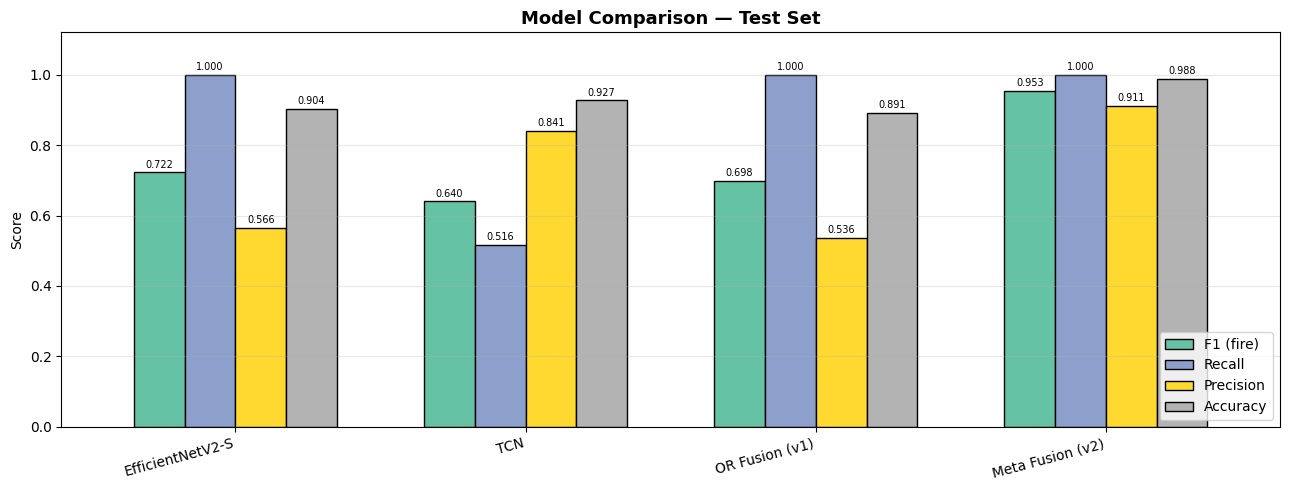

In [57]:
# ── Side-by-side metrics table ───────────────────────────────────────────────
def metrics_dict(y_true, y_pred):
    return {
        'F1 (fire)' : f1_score(y_true, y_pred),
        'Recall'    : recall_score(y_true, y_pred),
        'Precision' : precision_score(y_true, y_pred, zero_division=0),
        'Accuracy'  : accuracy_score(y_true, y_pred),
    }

results = pd.DataFrame({
    'EfficientNetV2-S'  : metrics_dict(y_test_aligned, eff_preds_test),
    'TCN'               : metrics_dict(y_test_aligned, tcn_preds_test),
    'OR Fusion (v1)'    : metrics_dict(y_test_aligned, or_fusion_preds),
    'Meta Fusion (v2)'  : metrics_dict(y_test_aligned, fusion_preds),
}).T

print(results.round(4).to_string())

fig, ax = plt.subplots(figsize=(13, 5))
results.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.7)
ax.set_title('Model Comparison — Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.12)
ax.set_xticklabels(results.index, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig('/content/model_comparison_bar.png', dpi=120, bbox_inches='tight')
plt.show()

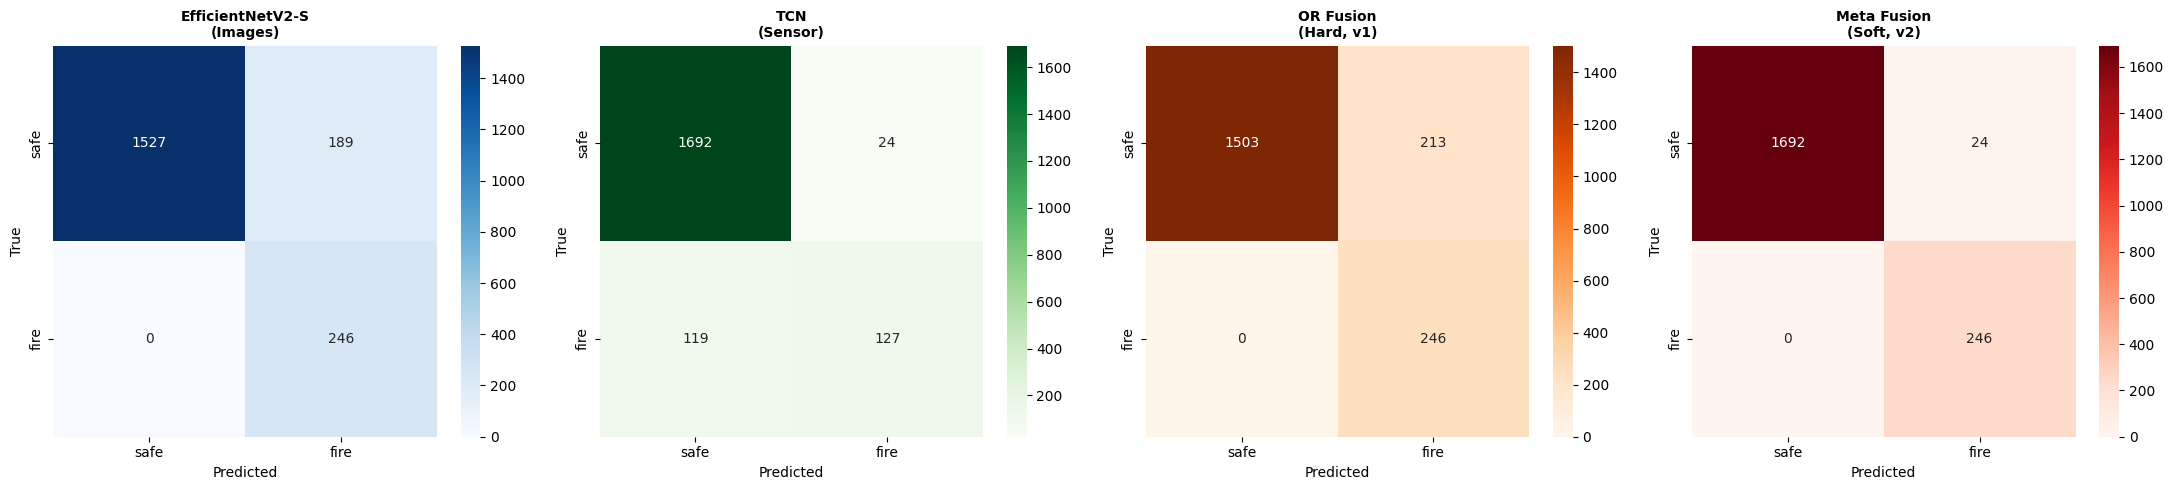

In [71]:
# ── Confusion matrix grid: all 4 models ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

models_info = [
    ('EfficientNetV2-S\n(Images)',    y_test_aligned, eff_preds_test,    'Blues'),
    ('TCN\n(Sensor)',                 y_test_aligned, tcn_preds_test,    'Greens'),
    ('OR Fusion\n(Hard, v1)',         y_test_aligned, or_fusion_preds,   'Oranges'),
    ('Meta Fusion\n(Soft, v2)',       y_test_aligned, fusion_preds,      'Reds'),
]
for ax, (title, yt, yp, cmap) in zip(axes, models_info):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['safe','fire'], yticklabels=['safe','fire'])
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('/content/all_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

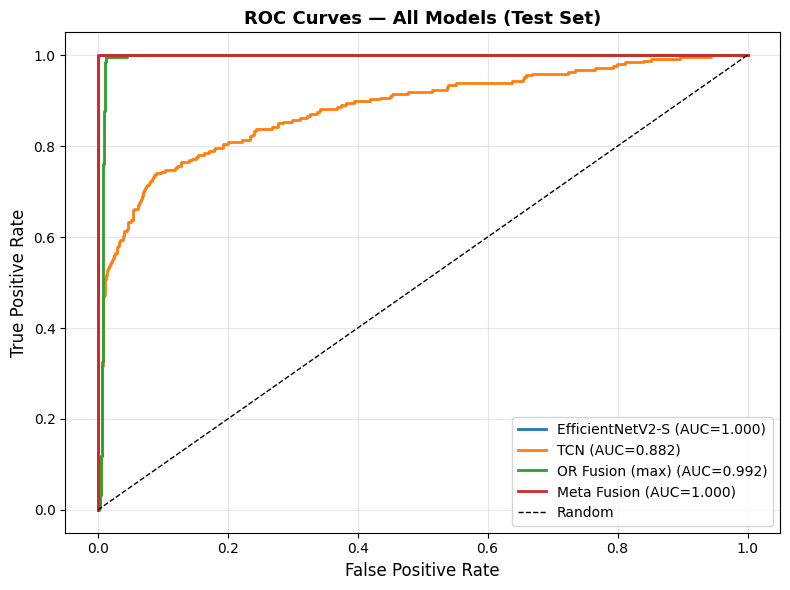

In [64]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for name, probs in [
    ('EfficientNetV2-S',   eff_probs_test_aligned),
    ('TCN',                tcn_probs_test_aligned),
    ('OR Fusion (max)',     np.maximum(eff_probs_test_aligned, tcn_probs_test_aligned)),
    ('Meta Fusion',        fusion_probs),
]:
    fpr, tpr, _ = roc_curve(y_test_aligned, probs)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (Test Set)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Save Models

In [82]:
import pickle, os

SAVE_DIR = '/content/drive/MyDrive/2301AI42/CAPSTONE/fire_detection_models_upgraded'
os.makedirs(SAVE_DIR, exist_ok=True)

effnet_model.save(os.path.join(SAVE_DIR, 'effnetv2s_model.keras'))
model_tcn.save(os.path.join(SAVE_DIR, 'tcn_model.keras'))

with open(os.path.join(SAVE_DIR, 'scaler_tcn.pkl'), 'wb') as f:
    pickle.dump(scaler_tcn, f)

with open(os.path.join(SAVE_DIR, 'meta_model.pkl'), 'wb') as f:
    pickle.dump(meta_model, f)

meta = {
    'TCN_FEATURES'    : TCN_FEATURES,
    'SEQ_LEN'         : SEQ_LEN,
    'TCN_THRESHOLD'   : float(TCN_THRESHOLD),
    'EFFNET_THRESHOLD': float(EFFNET_THRESHOLD),
    'EFFNET_SIZE'     : EFFNET_SIZE,
    'fire_idx_effnet' : int(fire_idx_effnet),
}
with open(os.path.join(SAVE_DIR, 'meta.pkl'), 'wb') as f:
    pickle.dump(meta, f)

print('All models saved to:', SAVE_DIR)

All models saved to: /content/drive/MyDrive/2301AI42/CAPSTONE/fire_detection_models_upgraded
